# Correlation lag–τ result grid

This is the plot-only correlation summary grid. It loads the portable, precomputed
assignment table and renders correlation magnitude by `(E, τ)` across the original,
linear-detrended, and 1-kyr high-pass experiments. The correlation experiments
themselves are computed separately, in [Calculate Correlation vs. Lag/Tau](1_calc__corr_lag_tau_resultsgrid.ipynb).

This produces Fig. S8, laid out identically to the Δρ/ρ/lag result grids in
[`3_CCM_multi_dyad`](../3_CCM_multi_dyad/_overview.md) (same dyads-as-columns, treatments-as-rows layout, same half-moon
surrogate-significance convention), but colored by |Pearson r| instead of CCM skill.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from cedarkit.core.relationship import Relationship
from cedarkit.viz.panels import ResultsGrid
from cedarkit.viz.grids import GridCell, SummaryGrid
from cedarkit.utils.plotting import save_figure

sns.set_theme(style="ticks", context="talk")
lag_ts_limit = 20
notebook_name = "plot__corr_lag_tau_resultsgrid"


stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])
figures_dir = stem / "figures" / notebook_name
figures_dir.mkdir(parents=True, exist_ok=True)
assignment_path = stem / "hol_temp_tsi_ccm" / "mixed" / "tmp" / "corr_assignment_summarygrid.parquet"



## Canonical plotting layout and rendering helpers


In [2]:
pair_specs = [
    ('Tian-Wu', 'Tian22HT115kaALLGMST_Wu18TSI', 'Tian22HT115kaALLGMSTLinear_Wu18TSILinear', 'tian22ht115kaallgmst1kyrfir_wu18tsianom1kyrfir', False),
    ('Erb-Wu', 'Erb22daGMST_Wu18TSI', 'Erb22daGMSTLinear_Wu18TSILinear', 'erb22dagmst1kyrfir_wu18tsianom1kyrfir', False),
    ('Erb-Vieira', 'Erb22daGMST_Vieira11TSI', 'Erb22daGMSTLinear_Vieira11TSILinear', 'erb22dagmst1kyrfir_vieira11tsianom1kyrfir', False),
    ('Alley-Wu', 'GISP2Alley00Tanom_Wu18TSI', 'GISP2Alley00TanomLinear_Wu18TSILinear', 'alley00gisp2multiproxy1kyrfir_wu18tsianom1kyrfir', False),
    ('Alley-Vieira', 'GISP2Alley00Tanom_Vieira11TSI', 'GISP2Alley00TanomLinear_Vieira11TSILinear', 'alley00gisp2multiproxy1kyrfir_vieira11tsianom1kyrfir', False),
    ('Doering-Wu', 'GISP2Doering22T15N_Wu18TSI', 'GISP2Doering22T15NLinear_Wu18TSILinear', 'doering22gisp2t15n1kyrfir_wu18tsianom1kyrfir', True),
    ('GISP2 Seierstad-Wu', 'GISP2Seierstad14d18O_Wu18TSI', 'GISP2Seierstad14d18OLinear_Wu18TSILinear', 'seierstad14gisp2d18o1kyrfir_wu18tsianom1kyrfir', False),
    ('NGRIP Seierstad-Wu', 'NGRIP1Seierstad14d18O_Wu18TSI', 'NGRIP1Seierstad14d18OLinear_Wu18TSILinear', 'seierstad14ngrip1d18o1kyrfir_wu18tsianom1kyrfir', False),
    ('GISP2 Martin-Wu', 'GISP2Martin24Tanom_Wu18TSI', 'GISP2Martin24TanomLinear_Wu18TSILinear', 'martin24gisp2tanom1kyrfir_wu18tsianom1kyrfir', False),
    ('NGRIP Martin-Wu', 'NGRIPMartin24Tanom_Wu18TSI', 'NGRIPMartin24TanomLinear_Wu18TSILinear', 'martin24ngriptanom1kyrfir_wu18tsianom1kyrfir', False),
]
# Pandas>=3 compatibility for lag-mode heatmap indexing in ResultsGrid.
def _to_lag_index_df_compat(pivot_df, lag_to_index):
    if hasattr(pivot_df, 'map'):
        out = pivot_df.map(lambda val: lag_to_index.get(int(val), np.nan) if pd.notna(val) else np.nan)
    else:
        out = pivot_df.applymap(lambda val: lag_to_index.get(int(val), np.nan) if pd.notna(val) else np.nan)
    return out




from cedarkit.viz.grids import GridCell, SummaryGrid

def _sparse_cbar_ticks_local(cbar_ax, lag_values, max_ticks=9):
    if cbar_ax is None or len(lag_values) == 0:
        return
    vals = [int(v) for v in lag_values]
    n = len(vals)
    anchors = [-20, -10, -3, 0, 3, 10, 20]
    anchor_idx = [i for i, v in enumerate(vals) if v in anchors]
    if n <= max_ticks:
        idx = list(range(n))
    else:
        step = int(np.ceil((n - 1) / max(1, (max_ticks - 1))))
        idx = list(range(0, n, step))
        if idx[-1] != n - 1:
            idx.append(n - 1)
        idx = sorted(set(idx + anchor_idx))
    cbar_ax.set_yticks(idx)
    cbar_ax.set_yticklabels([str(vals[i]) for i in idx])


def _canonical_pair_order():
    return [spec[0] for spec in pair_specs]


def _build_plot_scaffold(assign_df: pd.DataFrame, row_order, tau_values):
    pair_order = _canonical_pair_order()
    row_names = list(row_order)
    e_values = sorted(assign_df['E'].dropna().astype(int).unique().tolist()) if len(assign_df) > 0 else [1]
    if len(e_values) == 0:
        e_values = [1]

    scaffold = pd.MultiIndex.from_product(
        [pair_order, row_names, e_values, tau_values],
        names=['pair_label', 'row_category', 'E', 'tau']
    ).to_frame(index=False)

    main_cols = [
        'pair_label', 'row_category', 'E', 'tau', 'rho',
        'surr_rx_outperforming_frac', 'surr_ry_outperforming_frac',
        'var_x', 'var_y', 'role'
    ]
    available = [c for c in main_cols if c in assign_df.columns]
    main_df = assign_df.copy()
    if 'role' in main_df.columns:
        main_df = main_df[main_df['role'] == 'main'].copy()
    main_df = main_df[available].drop_duplicates(subset=['pair_label', 'row_category', 'E', 'tau'])

    out = scaffold.merge(main_df, on=['pair_label', 'row_category', 'E', 'tau'], how='left')

    pair_meta = (
        assign_df[['pair_label', 'var_x', 'var_y']]
        .dropna(subset=['pair_label'])
        .drop_duplicates(subset=['pair_label'])
    )
    out = out.merge(pair_meta, on='pair_label', how='left', suffixes=('', '_pair'))
    out['var_x'] = out['var_x'].fillna(out.get('var_x_pair'))
    out['var_y'] = out['var_y'].fillna(out.get('var_y_pair'))
    drop_cols = [c for c in ['var_x_pair', 'var_y_pair'] if c in out.columns]
    if drop_cols:
        out = out.drop(columns=drop_cols)

    return out, pair_order, row_names, e_values


def render_corr_summarygrid(assign_df, color_var='rho', row_order=None, tau_values=None, figsize_scale=(3.0, 2.7)):
    if row_order is None:
        row_order = ['original', 'lineardetrended', '1kyrfir']
    if tau_values is None:
        tau_values = sorted(assign_df['tau'].dropna().astype(int).unique().tolist())

    assign_df = assign_df.copy()
    if len(assign_df) == 0:
        raise RuntimeError('No data available for SummaryGrid rendering.')

    # Backward-compatible schema normalization.
    if 'rho' not in assign_df.columns and 'selected_rho' in assign_df.columns:
        assign_df['rho'] = assign_df['selected_rho']
    if 'lag' not in assign_df.columns and 'selected_lag' in assign_df.columns:
        assign_df['lag'] = assign_df['selected_lag']

    assign_plot, pair_order, row_names, e_values = _build_plot_scaffold(assign_df, row_order=row_order, tau_values=tau_values)

    # Ordering parity checks (Phase 1 contract)
    assert row_names == ['original', 'lineardetrended', '1kyrfir'], 'Row order must match canonical grid order.'
    assert pair_order == [spec[0] for spec in pair_specs], 'Pair order must match canonical pair_specs order.'

    pair_relationships = {}
    for pair_label in pair_order:
        sub = assign_plot[(assign_plot['pair_label'] == pair_label) & assign_plot['var_x'].notna() & assign_plot['var_y'].notna()]
        if len(sub) == 0:
            pair_relationships[pair_label] = Relationship(var_x='temp', var_y='TSI')
        else:
            first = sub.iloc[0]
            pair_relationships[pair_label] = Relationship(var_x=first['var_x'], var_y=first['var_y'])

    rows = len(row_names)
    cols = len(pair_order)
    gridplot = SummaryGrid(rows, cols + 1, width_ratios=[1] * cols + [0.1])
    gridplot.set_font_sizes(context='talk', multiplier=1.4)
    gridplot.make_grid(figsize=(figsize_scale[0] * cols, figsize_scale[1] * rows), wspace=.08, hspace=-.0301)

    if color_var == 'lag':
        gridplot.palette = sns.color_palette('coolwarm', as_cmap=True)
        gridplot.discrete_lag_mode = True
        lag_vals = list(range(-lag_ts_limit, lag_ts_limit + 1))
        gridplot.discrete_lag_values = lag_vals
        gridplot.cbar_label = 'Optimal lag (timesteps)'
    else:
        pal = sns.cubehelix_palette(start=.18, rot=-.28, light=1, dark=0, gamma=1, reverse=False, as_cmap=True)
        gridplot.palette = pal
        gridplot.discrete_lag_mode = False
        vmin = 0
        vmax = .4
        if np.isclose(vmin, vmax):
            vmin -= 1e-6
            vmax += 1e-6
        gridplot.vlims = [vmin, vmax]
        gridplot.cbar_label = 'Correlation (|r|)'

    gridplot.default_ylabel = 'tau'

    row_names_display = {
        'original': 'Untreated',
        'lineardetrended': 'Linear Detrend',
        '1kyrfir': '1kyr high-pass',
    }
    for ip, pair_label in enumerate(pair_order):
        for ik, row_name in enumerate(row_names):
            ax = gridplot.get_ax(ik, ip)
            sub = assign_plot[(assign_plot['pair_label'] == pair_label) & (assign_plot['row_category'] == row_name)].copy()

            if len(sub) == 0 or sub['rho'].notna().sum() == 0:
                gridplot.set_ax(ik, ip, ax, entry_type='spacer')
                continue

            scaffold = pd.MultiIndex.from_product([e_values, tau_values], names=['E', 'tau']).to_frame(index=False)
            data_cols = ['E', 'tau', 'rho', 'surr_rx_outperforming_frac', 'surr_ry_outperforming_frac']
            if 'lag' in sub.columns:
                data_cols.insert(2, 'lag')
            sub = sub[[c for c in data_cols if c in sub.columns]].copy()
            plot_df = scaffold.merge(sub, on=['E', 'tau'], how='left')
            if 'lag' not in plot_df.columns:
                plot_df['lag'] = np.nan
            if 'rho' not in plot_df.columns:
                plot_df['rho'] = np.nan

            if color_var == 'lag':
                plot_df = plot_df.rename(columns={'lag': 'selected_lag'})
                plot_df['selected_lag_pos'] = np.nan
                plot_df['has_tie'] = False
            else:
                plot_df = plot_df[['E', 'tau', 'rho', 'surr_rx_outperforming_frac', 'surr_ry_outperforming_frac']]

            gc = GridCell(ik, ip, output=plot_df)
            if ik == 2:
                gc.row_labels = []
            if ip==0:
                gc.row_labels = [row_names_display[row_name], r'$\tau$']
            gc.title_labels = [pair_label]
            gc.relationships = pair_relationships.get(pair_label, Relationship())
            if color_var == 'lag' and len(gridplot.discrete_lag_values) > 0:
                gc.ylims = [min(gridplot.discrete_lag_values), max(gridplot.discrete_lag_values)]
            else:
                gc.ylims = gridplot.vlims if len(gridplot.vlims) == 2 else [0.0, 1.0]

            outline_color = 'lightgray' if plot_df.rho.max()<.05 else None

            res = ResultsGrid(
                gc.relationships,
                ax=ax,
                palette=gridplot.palette,
                hue_var='rho',
                lag_mode='unrestricted',
                show_corner=False,
                show_half_moons=True,
                show_peak_circles=False,
                # x_var = 'tau',
                # y_var = 'E',
                outline_color=outline_color,
            )
            res.populate_from_cellobj(gc)
            if color_var == 'lag':
                res.set_discrete_lag_domain(gridplot.discrete_lag_values)
            res.plot_heatmap(gc.output)
            res.add_half_moons(gc.output)
            res.tidy_grid()
            if ik > 0:
                res.ax.set_title('')
            if ip > 0:
                res.ax.set(ylabel='', yticklabels=[], yticks=[])

            # if ik == len(row_names) - 1:
            #     res.ax.set_xlabel(r'$\tau$', labelpad=10)
            # else:
            res.ax.set(xlabel='', xticks=[])

            gridplot.add_handles_labels(res.line_handles, res.line_labels, kind='line')
            gridplot.set_ax(ik, ip, res.ax, entry_type='heatmap')
            gridplot.marker_d.update(res.marker_d)
            gridplot.sizes = res.sizes

    for r in range(1, rows):
        spacer = gridplot.get_ax(r, cols)
        if spacer is not None:
            gridplot.set_ax(r, cols, spacer, entry_type='spacer')

    gridplot.make_colorbar()
    if color_var == 'lag':
        _sparse_cbar_ticks_local(gridplot.cbar_ax, gridplot.discrete_lag_values, max_ticks=9)
    if rows > 1:
        try:
            if len(gridplot.line_handles) >= 2:
                gridplot.create_custom_legend(bbox_to_anchor=(0, .95))
            else:
                gridplot.create_lag_legend(bbox_to_anchor=(0, .95))
        except Exception as e:
            print('Legend fallback skipped:', e)


    try:
        gridplot.tidy_rows(ylim_by='row', supylabel_offset=.105, title_rows=[0])
    except UnboundLocalError:
        # Some sparse/blank-grid combinations can trip tidy_rows internals.
        # Grid is still valid; skip row-ylim normalization in this edge case.
        pass
    gridplot.get_ax(2, ip+1).remove()
    return gridplot


## Load the precomputed assignment table


In [3]:
assert assignment_path.is_file(), f"Missing correlation assignment table: {assignment_path}"
assignment_plot_df = pd.read_parquet(assignment_path)

row_order = ["original", "lineardetrended", "1kyrfir"]
pair_order = [spec[0] for spec in pair_specs]
assignment_plot_df = assignment_plot_df.loc[
    assignment_plot_df["row_category"].isin(row_order)
].copy()
assignment_plot_df["pair_label"] = pd.Categorical(
    assignment_plot_df["pair_label"], categories=pair_order, ordered=True
)
assignment_plot_df["row_category"] = pd.Categorical(
    assignment_plot_df["row_category"], categories=row_order, ordered=True
)
assignment_plot_df = assignment_plot_df.sort_values(
    ["pair_label", "row_category", "E", "tau"]
).reset_index(drop=True)

print(f"Loaded {len(assignment_plot_df):,} correlation assignment rows.")


Loaded 210 correlation assignment rows.


## Render correlation magnitude


/Users/jlanders/PycharmProjects/CCM_software/cedar_util/cedarkit/viz/grids.py:586: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/figures/plot__corr_lag_tau_resultsgrid/FigS8__corr_grid.pdf


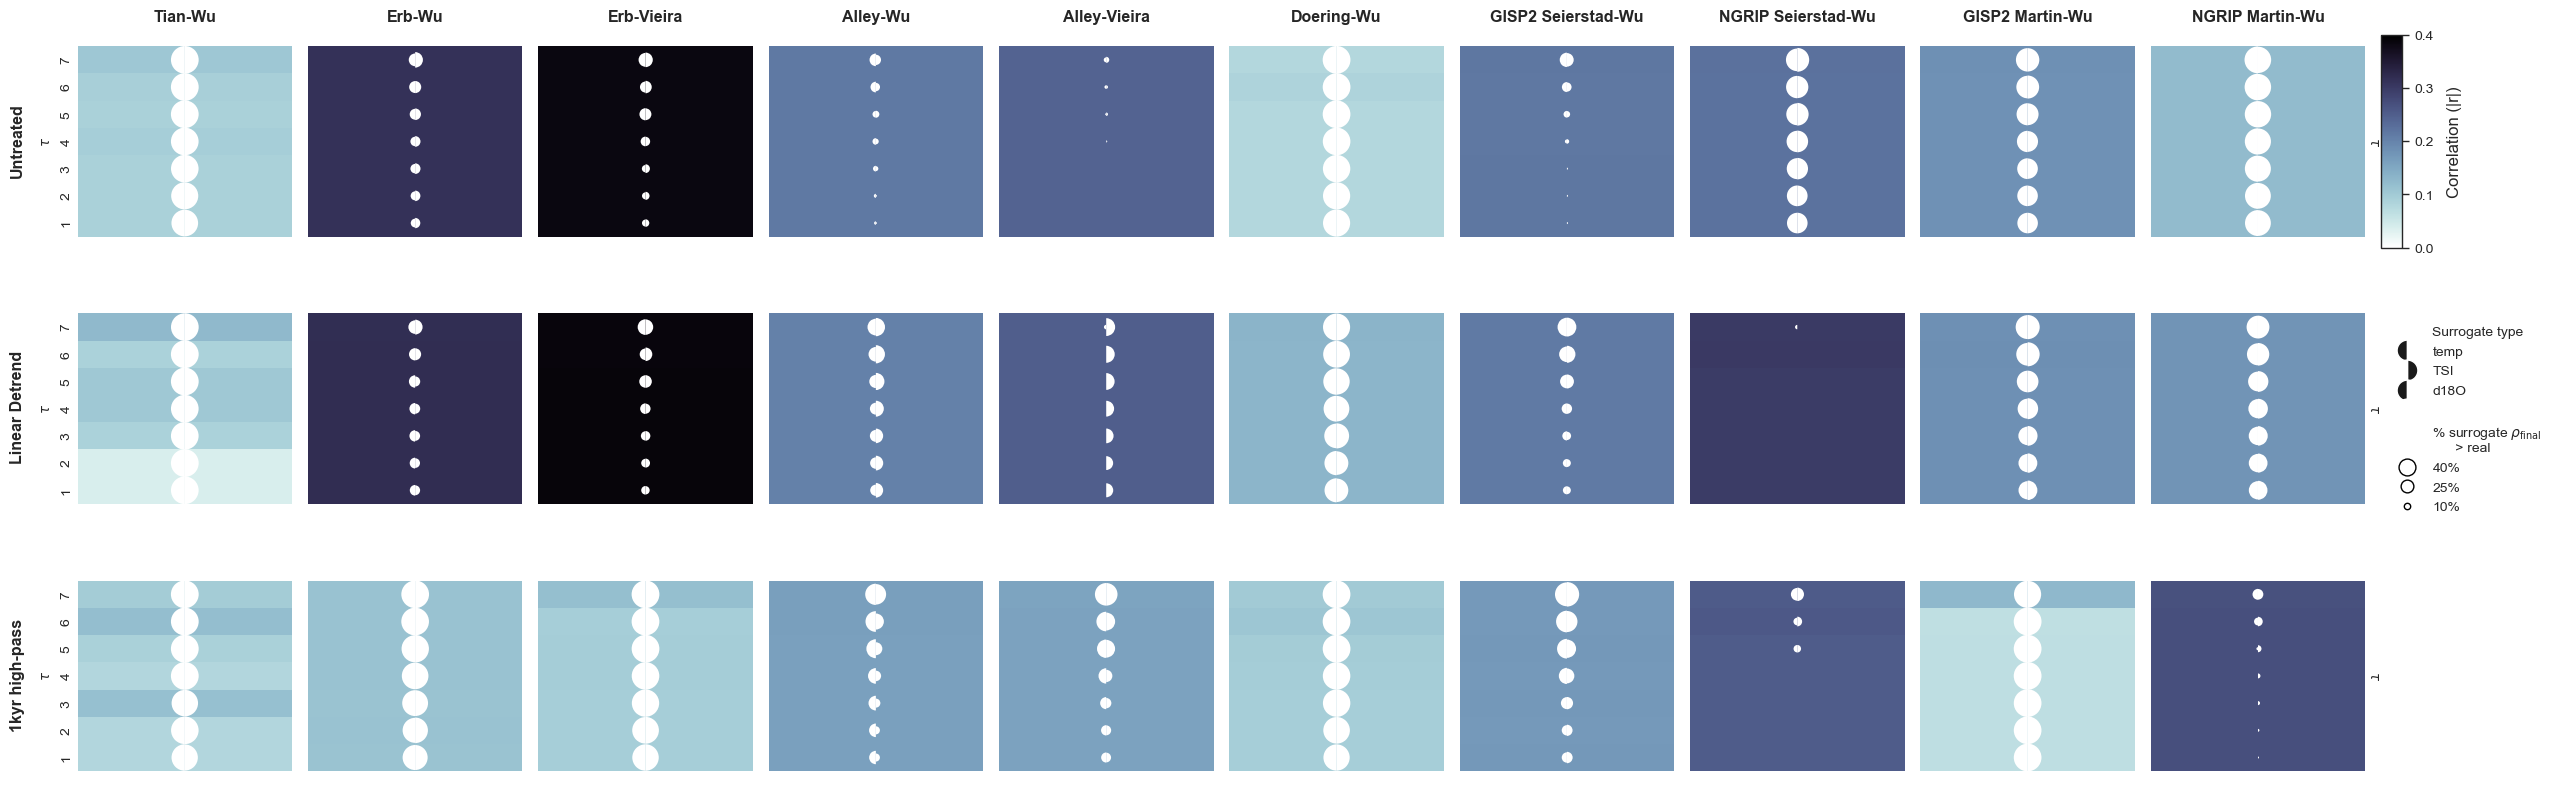

In [4]:
grid_rho = render_corr_summarygrid(
    assignment_plot_df,
    color_var="rho",
    row_order=["original", "lineardetrended", "1kyrfir"],
)
save_figure(grid_rho.fig, figures_dir, stem="FigS8__corr_grid", dry_run=True)


### Interpretation

Simple correlation comes out insignificant against surrogates in most cases here,
and the few significant relationships are scattered across dyads and treatments
without any single dyad holding up consistently. That's a weaker, less consistent
picture than CCM's roughly 80% discernible-influence rate. A dominant, linear TSI
driver would be expected to produce consistent significant correlation, which
these results don't show (Fig. S10 quantifies the CCM-minus-correlation skill gap
directly).
